In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import logging
import os
import sys

import h5py
import healpy as hp
import numpy as np

sys.path.append(os.path.join(os.getcwd(), ".."))
from scripts.utils import remove_mono_dipole, setup_logging, plot_predictions
from scripts import core, Core

from notebooks.ksw_joblib import KSW_joblib

# Monkey patch the core module
core.KSW = KSW_joblib

In [32]:
logger = setup_logging(__name__, level=logging.DEBUG)

## Heidelberg

In [33]:
core = Core(
    [
        "settings/heidelberg.json",
        "--nsims",
        "100",
        "--narray",
        "10",
        "--polarizations",
        "TE",
    ]
)

24-May-24 12:00:30 - scripts.core - DEBUG - Parsing CLI args: ['settings/heidelberg.json', '--nsims', '100', '--narray', '10', '--polarizations', 'TE']
24-May-24 12:00:30 - scripts.core - INFO - Loading settings from file settings/heidelberg.json
24-May-24 12:00:30 - scripts.core - DEBUG - Forcing setting 'nsims' to '100' due to CLI
24-May-24 12:00:30 - scripts.core - DEBUG - Forcing setting 'narray' to '10' due to CLI
24-May-24 12:00:30 - scripts.core - DEBUG - Forcing setting 'polarizations' to 'TE' due to CLI
24-May-24 12:00:30 - scripts.core - DEBUG - Found non-default value for 'cosmo_params': {'H0': 70.1, 'As': 2.457e-09, 'pivot_scalar': 0.002, 'ns': 0.96, 'ombh2': 0.02256, 'omch2': 0.1143, 'tau': 0.084, 'max_l': 1500, 'lmax': 1024} (default: {'As': 2.13e-09, 'ns': 0.9624, 'pivot_scalar': 0.05, 'max_l': 1000, 'lmax': 500})
24-May-24 12:00:30 - scripts.core - DEBUG - Overriding cosmo param As from 2.13e-09 to 2.457e-09
24-May-24 12:00:30 - scripts.core - DEBUG - Overriding cosmo p

24-May-24 12:00:52 - scripts.core - DEBUG - Setting up data and KSW
24-May-24 12:00:52 - scripts.core - INFO - beam (2, 1025), noise (3, 1025), pols ['T', 'E'], npols 2
24-May-24 12:00:52 - notebooks.ksw_joblib - INFO - Using KSW_joblib
24-May-24 12:00:52 - scripts.core - DEBUG - done with KSW
24-May-24 12:00:52 - scripts.core - DEBUG - Setting 'patch_side_deg' not found, using default: 10
24-May-24 12:00:52 - scripts.core - DEBUG - Found non-default value for 'npatches': 10 (default: 2)
24-May-24 12:00:52 - scripts.core - DEBUG - Setting 'base_dir' not found, using default: 'data'
24-May-24 12:00:52 - scripts.core - DEBUG - Found non-default value for 'base_name': 'heidelberg' (default: 'l1024_n512_ul_TE')
24-May-24 12:00:52 - scripts.core - INFO - Base name: heidelbergx2000
24-May-24 12:00:52 - scripts.core - DEBUG - Setting 'plot_dir' not found, using default: 'plots'
24-May-24 12:00:52 - scripts.core - DEBUG - Setting 'tb_dir' not found, using default: 'tensorboard'
24-May-24 12:00

In [34]:
def alm_step_loader(idx):
    return core.data.compute_alm_sim(core.lensing)


print("num cpus available:", len(os.sched_getaffinity(0)))
thetas = int(np.floor(1.5 * core.lmax + 1)) // len(os.sched_getaffinity(0))

# TODO:
# the ksw estimator should only depend on the sim settings and not the num sims
# would need to change the base_name form
# look into later

mc_path = os.path.join(core.base_dir, "kswmc")
os.makedirs(mc_path, exist_ok=True)
mc_file = os.path.join(mc_path, f"{core.base_name}.hdf5")

if os.path.exists(mc_file):
    logger.info("Loading KSW state from %s", mc_file)
    core.ksw.start_from_read_state(mc_file, None)
else:
    core.ksw.step_batch(alm_step_loader, range(100), theta_batch=thetas)

    logger.info("Saving KSW state to %s", mc_file)
    core.ksw.write_state(mc_file)

num cpus available: 64
24-May-24 12:00:52 - __main__ - INFO - Loading KSW state from data/kswmc/heidelbergx2000.hdf5


In [35]:
fisher = float(core.ksw.compute_fisher())
fisher, np.sqrt(1 / fisher)

(0.08905499115935527, 3.3509725292056936)

In [36]:
# num_estimates = 100

# fnls = np.random.uniform(core.fnl_min, core.fnl_max, num_estimates)
# idxs = range(1, num_estimates)


# def alm_hei_loader(idx):
#     str_idx = str(idx).zfill(4)
#     base1 = f"data/heidelberg/alm_l_{str_idx}_v3.fits"
#     base2 = f"data/heidelberg/alm_nl_{str_idx}_v3.fits"

#     alm_heidelberg_l = np.array(hp.read_alm(base1, hdu=1))
#     alm_heidelberg_nl = np.array(hp.read_alm(base2, hdu=1))
#     fnl = fnls[idx]

#     alm = alm_heidelberg_l + fnl * alm_heidelberg_nl
#     alm *= 2.7255 * 10 ** (6)  # convert heidelberg to uK
#     alm = remove_mono_dipole(alm)

#     logger.info("sending idx: %s, fnl: %s" % (idx, fnl))
#     return alm


# hei_estimates = core.ksw.compute_estimate_batch(alm_hei_loader, idxs, fisher=fisher, theta_batch=thetas)

In [37]:
# plot_predictions(fnls[idxs], hei_estimates, fisher=fisher)

## Sim

In [40]:
alm_file = h5py.File(core.alm_file, "r", swmr=True, locking=False)
alms = alm_file["alm"]
fnls = alm_file["fnl"]

def estimator_loader(idx):
    """Loads in a single alm given an idx."""
    print("sending idx: %s, fnl: %s" % (idx, fnls[idx]))
    return np.array(alms[int(idx)])


idxs = range(30)
sim_estimates = core.ksw.compute_estimate_batch(
    estimator_loader, idxs, fisher=fisher, theta_batch=thetas
)

sending idx: 0, fnl: [474.10248995]
24-May-24 12:02:29 - notebooks.ksw_joblib - DEBUG - t_cubic: 35.07016607967671, lin_term: 0.023673282624652313, fisher: 0.08905499115935527
24-May-24 12:02:29 - notebooks.ksw_joblib - INFO - estimate: 393.53765960562237
sending idx: 1, fnl: [10.44691846]
24-May-24 12:02:44 - notebooks.ksw_joblib - DEBUG - t_cubic: 1.2596275783130295, lin_term: -0.006314701093058811, fisher: 0.08905499115935527
24-May-24 12:02:44 - notebooks.ksw_joblib - INFO - estimate: 14.215287239103843
sending idx: 2, fnl: [461.44868603]
24-May-24 12:02:59 - notebooks.ksw_joblib - DEBUG - t_cubic: 35.715248764936405, lin_term: -0.029173308341659147, fisher: 0.08905499115935527
24-May-24 12:02:59 - notebooks.ksw_joblib - INFO - estimate: 401.3747192374304
sending idx: 3, fnl: [30.64905161]
24-May-24 12:03:14 - notebooks.ksw_joblib - DEBUG - t_cubic: 1.4704191965411155, lin_term: -0.07151287581635973, fisher: 0.08905499115935527
24-May-24 12:03:14 - notebooks.ksw_joblib - INFO - est

24-May-24 12:09:57 - scripts.utils.plots - DEBUG - Plotting with standard deviation: 3.3509725292056936


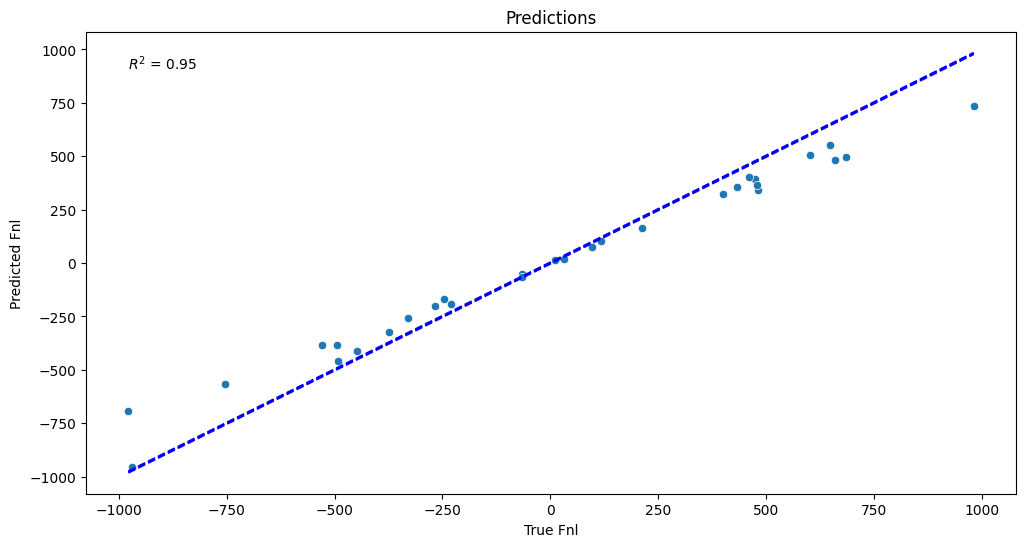

In [41]:
plot_predictions(fnls[idxs], sim_estimates, fisher=fisher)